# XGBoost Classification of CWRU Bearing Fault Size

Dataset: CWRU Bearing Data Center. Same task as the Random Forest notebook —
predict ball-fault severity (0.007in / 0.014in / 0.021in) from the Drive End
vibration signal, this time with `XGBClassifier`.

Pipeline: load `.mat` signals -> window into 1024-sample chunks -> extract 14
time-domain features -> train/evaluate XGBoost.

## 1. Imports and configuration

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.stats import skew, kurtosis

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
WINDOW_SIZE = 1024

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

np.random.seed(RANDOM_STATE)

## 2. Dataset configuration

Same three files/labels as the Random Forest notebook.

In [2]:
RAW_DIR = os.path.join("..", "raw")

FILE_LABELS = {
    "B007_1_123.mat": 0,
    "B014_1_190.mat": 1,
    "B021_1_227.mat": 2,
}

LABEL_NAMES = {
    0: "0.007 in fault",
    1: "0.014 in fault",
    2: "0.021 in fault",
}

FILE_LABELS

{'B007_1_123.mat': 0, 'B014_1_190.mat': 1, 'B021_1_227.mat': 2}

## 3. Loading signals and auto-detecting the DE_time channel

In [3]:
def load_de_signal(filepath):
    """Load a CWRU .mat file and return its Drive End (DE_time) signal as a 1-D array."""
    mat = loadmat(filepath)
    de_keys = [k for k in mat.keys() if k.endswith("DE_time")]
    if not de_keys:
        raise ValueError(f"No DE_time channel found in {filepath}")
    signal = mat[de_keys[0]].flatten()
    return signal


signals = {}
for fname, label in FILE_LABELS.items():
    path = os.path.join(RAW_DIR, fname)
    signals[fname] = load_de_signal(path)
    print(f"{fname:20s} label={label}  DE_time length={len(signals[fname])}")

B007_1_123.mat       label=0  DE_time length=487384
B014_1_190.mat       label=1  DE_time length=486224
B021_1_227.mat       label=2  DE_time length=486804


## 4. Segmenting signals into fixed-length windows

In [4]:
def window_signal(signal, window_size=WINDOW_SIZE):
    """Split a 1-D signal into non-overlapping windows of `window_size` samples."""
    n_windows = len(signal) // window_size
    trimmed = signal[: n_windows * window_size]
    return trimmed.reshape(n_windows, window_size)


windowed_signals = {}
for fname, signal in signals.items():
    windowed_signals[fname] = window_signal(signal)
    print(f"{fname:20s} -> {windowed_signals[fname].shape[0]} windows of {WINDOW_SIZE} samples")

B007_1_123.mat       -> 475 windows of 1024 samples
B014_1_190.mat       -> 474 windows of 1024 samples
B021_1_227.mat       -> 475 windows of 1024 samples


## 5. Time-domain feature extraction

Same 14 statistical features as the Random Forest notebook (mean, std, variance,
RMS, max/min, peak-to-peak, energy, crest/shape/impulse/margin factor, skewness,
kurtosis).

In [5]:
def extract_features(window):
    """Compute 14 time-domain statistical features for a single window."""
    mean = np.mean(window)
    std = np.std(window)
    var = np.var(window)
    rms = np.sqrt(np.mean(window ** 2))
    maximum = np.max(window)
    minimum = np.min(window)
    peak_to_peak = maximum - minimum
    energy = np.sum(window ** 2)
    mean_abs = np.mean(np.abs(window))
    sqrt_abs_mean = np.mean(np.sqrt(np.abs(window))) ** 2

    crest_factor = maximum / rms if rms != 0 else 0
    shape_factor = rms / mean_abs if mean_abs != 0 else 0
    impulse_factor = maximum / mean_abs if mean_abs != 0 else 0
    margin_factor = maximum / sqrt_abs_mean if sqrt_abs_mean != 0 else 0

    return {
        "mean": mean,
        "std": std,
        "variance": var,
        "rms": rms,
        "max": maximum,
        "min": minimum,
        "peak_to_peak": peak_to_peak,
        "energy": energy,
        "crest_factor": crest_factor,
        "shape_factor": shape_factor,
        "impulse_factor": impulse_factor,
        "margin_factor": margin_factor,
        "skewness": skew(window),
        "kurtosis": kurtosis(window),
    }


sample_features = extract_features(windowed_signals["B007_1_123.mat"][0])
sample_features

{'mean': 0.01903676502403846,
 'std': 0.1216143454980048,
 'variance': 0.014790049030908081,
 'rms': 0.12309527794959697,
 'max': 0.35986153846153845,
 'min': -0.32606584615384615,
 'peak_to_peak': 0.6859273846153846,
 'energy': 15.51610619237226,
 'crest_factor': 2.923439017773603,
 'shape_factor': 1.246670166123362,
 'impulse_factor': 3.6445642059393357,
 'margin_factor': 4.300172415699153,
 'skewness': -0.03513870759458802,
 'kurtosis': -0.1680500072556277}

## 6. Building the feature DataFrame

In [6]:
rows = []
for fname, windows in windowed_signals.items():
    label = FILE_LABELS[fname]
    for w in windows:
        feats = extract_features(w)
        feats["label"] = label
        feats["file"] = fname
        rows.append(feats)

df = pd.DataFrame(rows)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1424, 16)


,mean,std,variance,rms,max,min,peak_to_peak,energy,crest_factor,shape_factor,impulse_factor,margin_factor,skewness,kurtosis,label,file
0,0.019037,0.121614,0.014790,0.123095,0.359862,-0.326066,0.685927,15.516106,2.923439,1.246670,3.644564,4.300172,-0.035139,-0.168050,0,B007_1_123.mat
1,0.016644,0.123797,0.015326,0.124911,0.333993,-0.418900,0.752893,15.977211,2.673851,1.262160,3.374828,4.018695,-0.196832,0.072405,0,B007_1_123.mat
2,0.023228,0.127644,0.016293,0.129740,0.410764,-0.361113,0.771877,17.236492,3.166049,1.209743,3.830106,4.410150,0.087703,-0.404993,0,B007_1_123.mat
3,0.021281,0.137092,0.018794,0.138734,0.467716,-0.336705,0.804421,19.708933,3.371323,1.280948,4.318489,5.173232,0.247407,0.145659,0,B007_1_123.mat
4,0.019683,0.158440,0.025103,0.159658,0.468550,-0.438092,0.906642,26.102540,2.934707,1.242678,3.646896,4.294137,0.006549,-0.401958,0,B007_1_123.mat


## 7. Class distribution

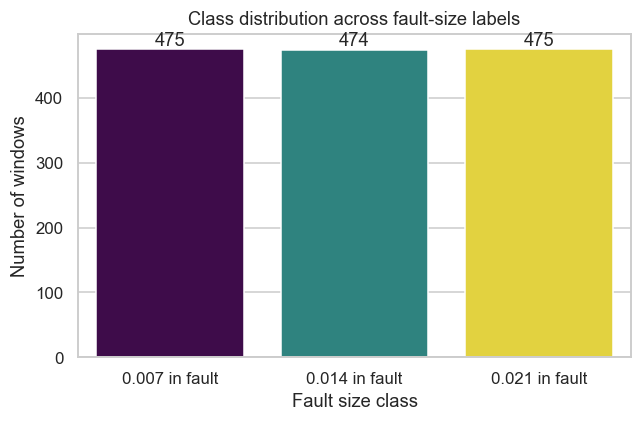

In [7]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="label", hue="label", palette="viridis", legend=False)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([LABEL_NAMES[i] for i in [0, 1, 2]])
ax.set_xlabel("Fault size class")
ax.set_ylabel("Number of windows")
ax.set_title("Class distribution across fault-size labels")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

## 8. Feature correlation heatmap

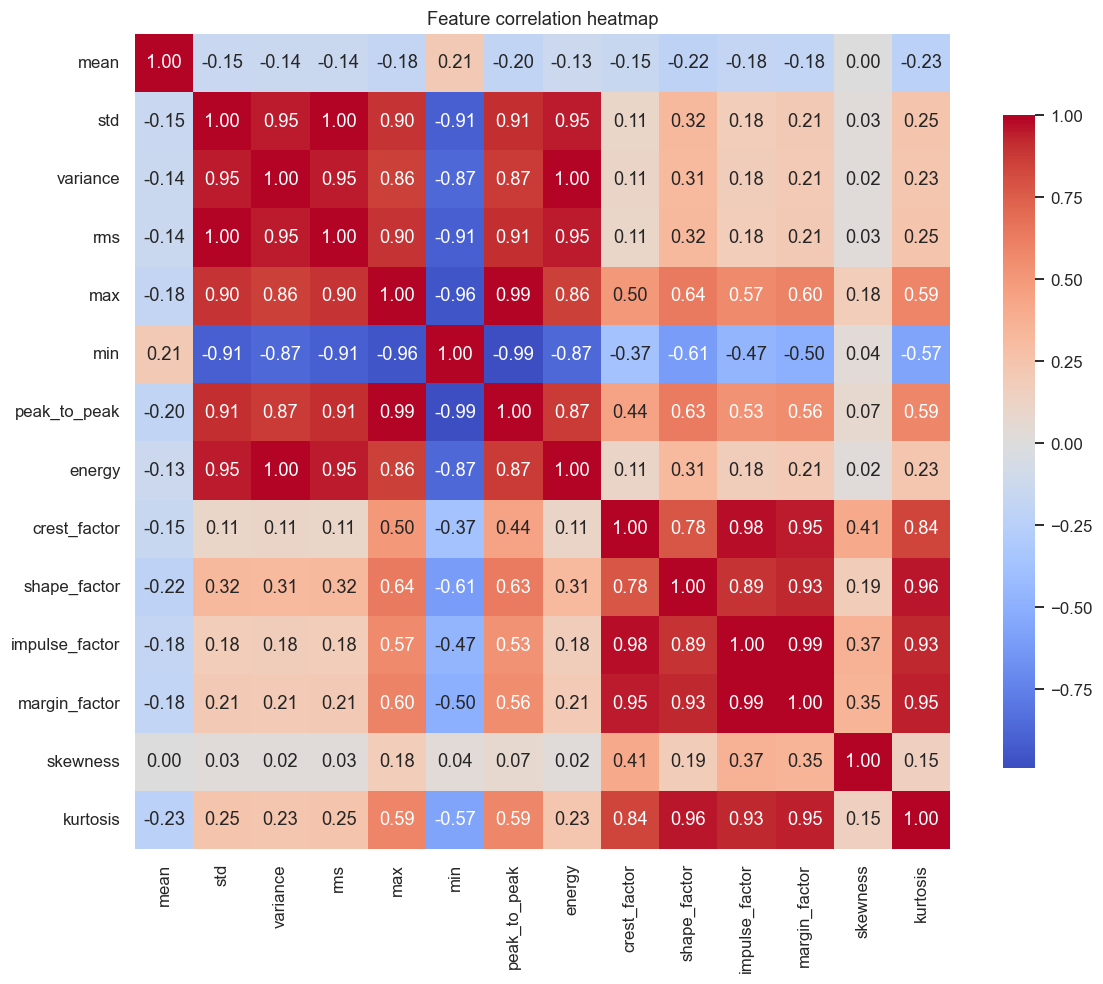

In [8]:
feature_cols = [c for c in df.columns if c not in ("label", "file")]

plt.figure(figsize=(11, 9))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

## 9. Train/test split and feature standardization

XGBoost splits on raw thresholds like Random Forest, so scaling isn't required,
but we keep it for a consistent pipeline across notebooks.

In [9]:
X = df[feature_cols].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape: ", X_test_scaled.shape)

Train shape: (1139, 14)
Test shape:  (285, 14)


## 10. Training the XGBoost classifier

`n_estimators=300`, `max_depth=6`, `learning_rate=0.1` — a standard starting
configuration for gradient-boosted trees on a small tabular dataset.

In [10]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_model.fit(X_train_scaled, y_train)
y_pred = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)

print("Model trained.")

Model trained.


## 11. Evaluation metrics

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (macro)")
print(f"Recall   : {recall:.4f}  (macro)")
print(f"F1 Score : {f1:.4f}  (macro)")

Accuracy : 0.9088
Precision: 0.9099  (macro)
Recall   : 0.9088  (macro)
F1 Score : 0.9089  (macro)


### Classification report

In [12]:
print(classification_report(
    y_test, y_pred,
    target_names=[LABEL_NAMES[i] for i in [0, 1, 2]]
))

                precision    recall  f1-score   support

0.007 in fault       0.89      0.94      0.91        95
0.014 in fault       0.96      0.91      0.93        95
0.021 in fault       0.88      0.88      0.88        95

      accuracy                           0.91       285
     macro avg       0.91      0.91      0.91       285
  weighted avg       0.91      0.91      0.91       285



## 12. Confusion matrix

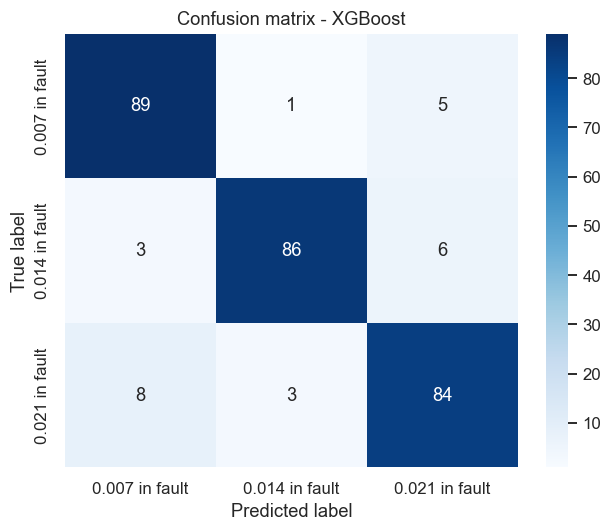

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[LABEL_NAMES[i] for i in [0, 1, 2]],
            yticklabels=[LABEL_NAMES[i] for i in [0, 1, 2]])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix - XGBoost")
plt.tight_layout()
plt.show()

## 13. 5-Fold Cross-Validation

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_scaled_full = scaler.fit_transform(X)
cv_scores = cross_val_score(xgb_model, X_scaled_full, y, cv=cv, scoring="accuracy")

print("Cross-validation accuracy per fold:", np.round(cv_scores, 4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")

Cross-validation accuracy per fold: [0.9158 0.9123 0.9088 0.9158 0.919 ]
Mean CV accuracy: 0.9143  (+/- 0.0035)


## 14. Feature importance

XGBoost exposes gain-based feature importance directly on the fitted booster.

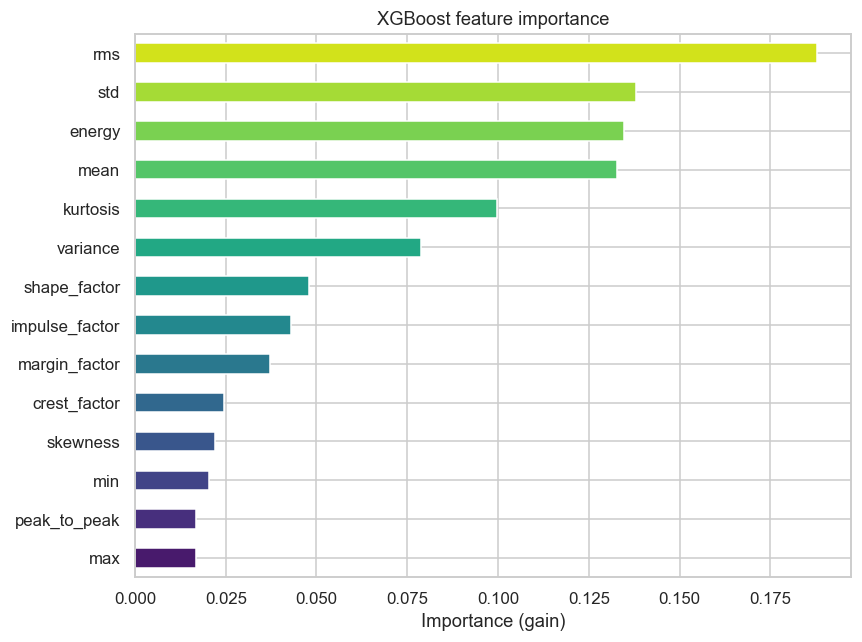

In [15]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color=sns.color_palette("viridis", len(importances)))
plt.xlabel("Importance (gain)")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()

## 15. ROC and Precision-Recall curves (one-vs-rest)

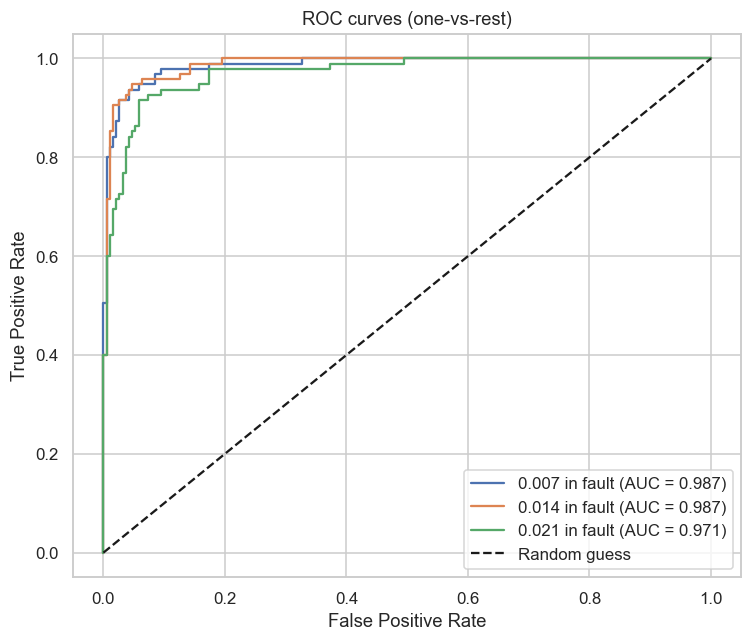

In [16]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(7, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{LABEL_NAMES[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves (one-vs-rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

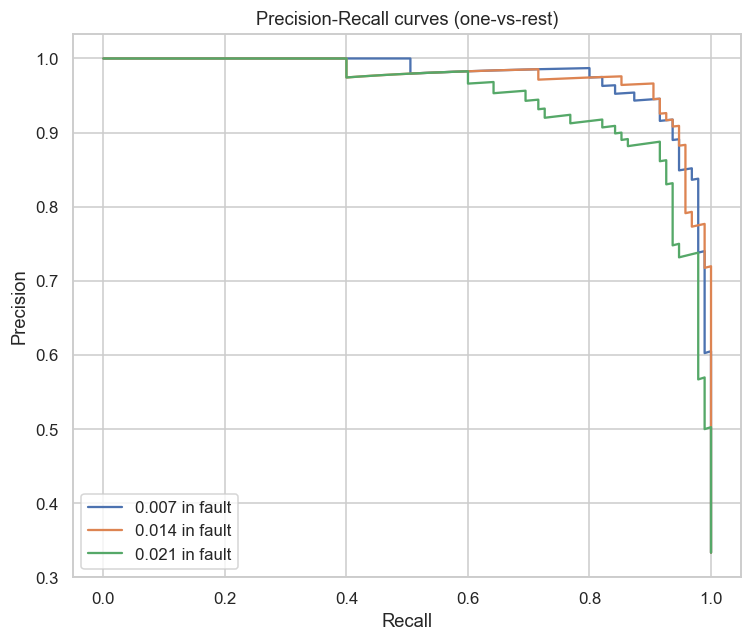

In [17]:
plt.figure(figsize=(7, 6))
for i in range(n_classes):
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(recall_curve, precision_curve, label=f"{LABEL_NAMES[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves (one-vs-rest)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 16. Summary

Same features and split as the Random Forest notebook, swapped in
`XGBClassifier` (gradient-boosted trees) instead of bagged trees. Compare the
accuracy/F1/CV numbers above against `Random_Forest_CWRU.ipynb` directly —
XGBoost typically edges out Random Forest on tabular data given similar
tuning, at the cost of more hyperparameters to tune and slightly higher
overfitting risk without regularization.